In [1]:
print("Python version:")
import sys
print(sys.version)

Python version:
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [1]:
# ============================================
# Credit Card Approval Prediction
# Final Research Notebook
# ============================================

import pandas as pd
import numpy as np
import sys
import warnings

from pycaret.classification import *
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

print("Python Version:", sys.version)

Python Version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [2]:
# Load dataset
DATA_PATH = "Application_Data.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (25128, 21)


,Applicant_ID,Applicant_Gender,Owned_Car,Owned_Realty,Total_Children,Total_Income,Income_Type,Education_Type,Family_Status,Housing_Type,...,Owned_Work_Phone,Owned_Phone,Owned_Email,Job_Title,Total_Family_Members,Applicant_Age,Years_of_Working,Total_Bad_Debt,Total_Good_Debt,Status
0,5008806,M,1,1,0,112500,Working ...,Secondary / secondary special ...,Married ...,House / apartment ...,...,0,0,0,Security staff ...,2,59,4,0,30,1
1,5008808,F,0,1,0,270000,Commercial associate ...,Secondary / secondary special ...,Single / not married ...,House / apartment ...,...,0,1,1,Sales staff ...,1,53,9,0,5,1
2,5008809,F,0,1,0,270000,Commercial associate ...,Secondary / secondary special ...,Single / not married ...,House / apartment ...,...,0,1,1,Sales staff ...,1,53,9,0,5,1
3,5008810,F,0,1,0,270000,Commercial associate ...,Secondary / secondary special ...,Single / not married ...,House / apartment ...,...,0,1,1,Sales staff ...,1,53,9,0,27,1
4,5008811,F,0,1,0,270000,Commercial associate ...,Secondary / secondary special ...,Single / not married ...,House / apartment ...,...,0,1,1,Sales staff ...,1,53,9,0,39,1


In [4]:
# Explanatory Data Analysis (EDA)
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25128 entries, 0 to 25127
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Applicant_ID          25128 non-null  int64 
 1   Applicant_Gender      25128 non-null  object
 2   Owned_Car             25128 non-null  int64 
 3   Owned_Realty          25128 non-null  int64 
 4   Total_Children        25128 non-null  int64 
 5   Total_Income          25128 non-null  int64 
 6   Income_Type           25128 non-null  object
 7   Education_Type        25128 non-null  object
 8   Family_Status         25128 non-null  object
 9   Housing_Type          25128 non-null  object
 10  Owned_Mobile_Phone    25128 non-null  int64 
 11  Owned_Work_Phone      25128 non-null  int64 
 12  Owned_Phone           25128 non-null  int64 
 13  Owned_Email           25128 non-null  int64 
 14  Job_Title             25128 non-null  object
 15  Total_Family_Members 


Distribusi Target:
Status
1    25007
0      121
Name: count, dtype: int64


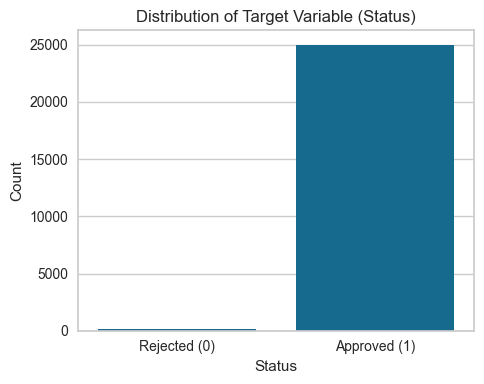

In [24]:
print("\nDistribusi Target:")
print(df["Status"].value_counts())

plt.figure(figsize=(5,4))

sns.countplot(
    x="Status",
    data=df,
)

plt.title("Distribution of Target Variable (Status)")
plt.xlabel("Status")
plt.ylabel("Count")

plt.xticks(
    ticks=[0,1],
    labels=["Rejected (0)", "Approved (1)"]
)

plt.tight_layout()
plt.show()


Persentase Target:
Status
1    99.518465
0     0.481535
Name: proportion, dtype: float64


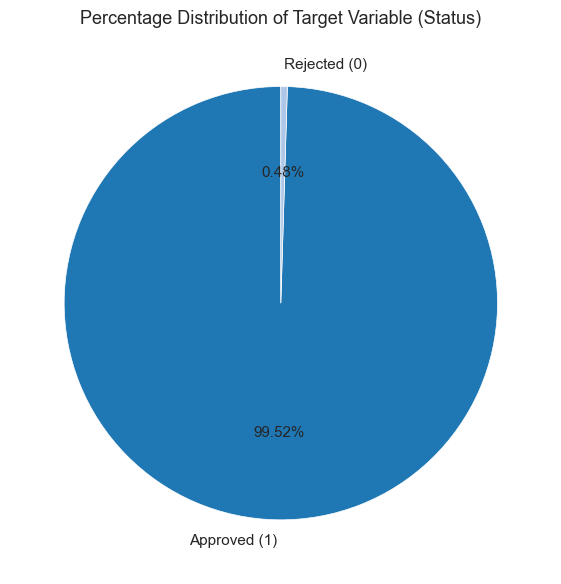

In [31]:
print("\nPersentase Target:") 
print(df["Status"].value_counts(normalize=True) * 100)

status_percent = df["Status"].value_counts(normalize=True) * 100

labels = ["Approved (1)", "Rejected (0)"]

# Warna gradasi biru
colors = ["#1f77b4", "#aec7e8"]

plt.figure(figsize=(6,6))

wedges, texts, autotexts = plt.pie(
    status_percent,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize':11},
    wedgeprops={'linewidth':0.5, 'edgecolor':'white'}
)

plt.title("Percentage Distribution of Target Variable (Status)", fontsize=13)
plt.tight_layout()
plt.show()

### Experiment 1 - Real Dataset (Imbalanced)

In [6]:
# Setup PyCaret
clf_setup = setup(
    data=df,
    target="Status",
    train_size=0.7,
    session_id=42,
    ignore_features=["Applicant_ID"],
    fix_imbalance=True,
    fold_strategy='stratifiedkfold',
    fold=5,
    normalize=True,
    verbose=False
)

In [7]:
# Compare models
best_model = compare_models(sort='Recall')

compare_results_original = pull()
compare_results_original

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9964,0.9983,1.0000,0.9964,0.9982,0.4092,0.5071,0.4100
et,Extra Trees Classifier,0.9959,0.9929,0.9995,0.9964,0.9979,0.3669,0.4266,0.2900
lightgbm,Light Gradient Boosting Machine,0.9992,0.9999,0.9994,0.9998,0.9996,0.9197,0.9211,0.3800
ada,Ada Boost Classifier,0.9990,0.9992,0.9993,0.9997,0.9995,0.9057,0.9073,0.5780
gbc,Gradient Boosting Classifier,0.9991,0.9998,0.9991,0.9999,0.9995,0.9160,0.9196,2.3720
dt,Decision Tree Classifier,0.9972,0.8698,0.9984,0.9987,0.9986,0.7150,0.7208,0.5940
svm,SVM - Linear Kernel,0.9951,0.9841,0.9961,0.9990,0.9975,0.6104,0.6283,0.4420
lr,Logistic Regression,0.9951,0.9941,0.9955,0.9995,0.9975,0.6359,0.6648,0.5560
knn,K Neighbors Classifier,0.9873,0.6406,0.9908,0.9964,0.9936,0.1668,0.1792,1.0920
ridge,Ridge Classifier,0.9491,0.9541,0.9502,0.9986,0.9737,0.1145,0.2085,0.0980


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9964,0.9983,1.0000,0.9964,0.9982,0.4092,0.5071,0.410
et,Extra Trees Classifier,0.9959,0.9929,0.9995,0.9964,0.9979,0.3669,0.4266,0.290
lightgbm,Light Gradient Boosting Machine,0.9992,0.9999,0.9994,0.9998,0.9996,0.9197,0.9211,0.380
ada,Ada Boost Classifier,0.9990,0.9992,0.9993,0.9997,0.9995,0.9057,0.9073,0.578
gbc,Gradient Boosting Classifier,0.9991,0.9998,0.9991,0.9999,0.9995,0.9160,0.9196,2.372
dt,Decision Tree Classifier,0.9972,0.8698,0.9984,0.9987,0.9986,0.7150,0.7208,0.594
svm,SVM - Linear Kernel,0.9951,0.9841,0.9961,0.9990,0.9975,0.6104,0.6283,0.442
lr,Logistic Regression,0.9951,0.9941,0.9955,0.9995,0.9975,0.6359,0.6648,0.556
knn,K Neighbors Classifier,0.9873,0.6406,0.9908,0.9964,0.9936,0.1668,0.1792,1.092
ridge,Ridge Classifier,0.9491,0.9541,0.9502,0.9986,0.9737,0.1145,0.2085,0.098


In [8]:
# Tune the best model
tuned_model = tune_model(best_model, optimize='Recall')

tuned_results_original = pull()
tuned_results_original

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9955,0.9915,0.9989,0.9966,0.9977,0.3825,0.4022
1,0.9980,0.9972,0.9997,0.9983,0.9990,0.7577,0.7693
2,0.9957,0.9957,0.9991,0.9966,0.9979,0.3981,0.4269
3,0.9957,0.9929,0.9983,0.9974,0.9979,0.5140,0.5165
4,0.9966,0.9912,0.9997,0.9969,0.9983,0.4986,0.5488
Mean,0.9963,0.9937,0.9991,0.9971,0.9981,0.5102,0.5327
Std,0.0009,0.0024,0.0005,0.0006,0.0005,0.1343,0.1302


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9955,0.9915,0.9989,0.9966,0.9977,0.3825,0.4022
1,0.9980,0.9972,0.9997,0.9983,0.9990,0.7577,0.7693
2,0.9957,0.9957,0.9991,0.9966,0.9979,0.3981,0.4269
3,0.9957,0.9929,0.9983,0.9974,0.9979,0.5140,0.5165
4,0.9966,0.9912,0.9997,0.9969,0.9983,0.4986,0.5488
Mean,0.9963,0.9937,0.9991,0.9971,0.9981,0.5102,0.5327
Std,0.0009,0.0024,0.0005,0.0006,0.0005,0.1343,0.1302


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9968,0.9976,0.9999,0.9969,0.9984,0.5187,0.5780


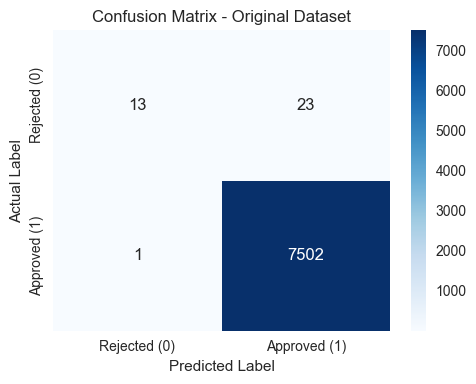


Classification Report - Original Dataset
              precision    recall  f1-score   support

           0       0.93      0.36      0.52        36
           1       1.00      1.00      1.00      7503

    accuracy                           1.00      7539
   macro avg       0.96      0.68      0.76      7539
weighted avg       1.00      1.00      1.00      7539



In [ ]:
# Predict holdout
holdout_pred = predict_model(tuned_model)

y_true = holdout_pred["Status"]
y_pred = holdout_pred["prediction_label"]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=["Rejected (0)", "Approved (1)"],
            yticklabels=["Rejected (0)", "Approved (1)"])

plt.title("Confusion Matrix - Original Dataset")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

print("\nClassification Report - Original Dataset")
print(classification_report(y_true, y_pred))

### Experiment 2 – Balanced Dataset (Undersampling)

In [3]:
# Manual balancing using downsampling
df_majority = df[df.Status == 1]
df_minority = df[df.Status == 0]

print("Sebelum Balancing:")
print(df.Status.value_counts())

df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

df_balanced = pd.concat([df_majority_downsampled, df_minority])

print("\nSetelah Balancing:")
print(df_balanced.Status.value_counts())

Sebelum Balancing:
Status
1    25007
0      121
Name: count, dtype: int64

Setelah Balancing:
Status
1    121
0    121
Name: count, dtype: int64


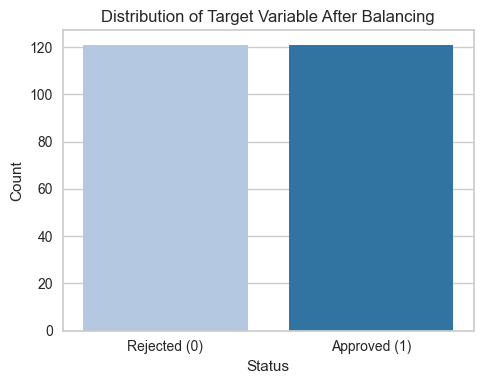

In [4]:
plt.figure(figsize=(5,4))

sns.countplot(
    x="Status",
    data=df_balanced,
    palette=["#aec7e8", "#1f77b4"]  # gradasi biru
)

plt.title("Distribution of Target Variable After Balancing", fontsize=12)
plt.xlabel("Status")
plt.ylabel("Count")

plt.xticks(
    ticks=[0,1],
    labels=["Rejected (0)", "Approved (1)"]
)

plt.tight_layout()
plt.show()

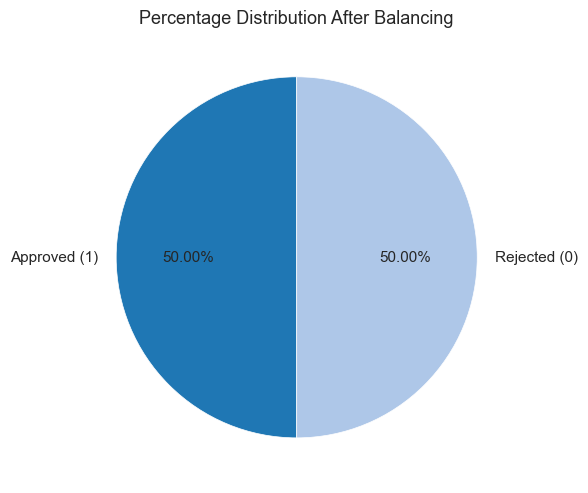

In [5]:
status_percent_bal = df_balanced["Status"].value_counts(normalize=True) * 100

labels = ["Approved (1)", "Rejected (0)"]

colors = ["#1f77b4", "#aec7e8"]  # gradasi biru konsisten

plt.figure(figsize=(6,6))

plt.pie(
    status_percent_bal,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize':11},
    wedgeprops={'linewidth':0.5, 'edgecolor':'white'}
)

plt.title("Percentage Distribution After Balancing", fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# Setup PyCaret with balanced dataset
clf_setup_bal = setup(
    data=df_balanced,
    target="Status",
    train_size=0.7,
    session_id=42,
    ignore_features=["Applicant_ID"],
    fold_strategy='stratifiedkfold',
    fold=3,
    normalize=True,
    verbose=False
)

In [12]:
# Compare models on balanced dataset
best_model_bal = compare_models(sort='F1')

compare_results_balanced = pull()
compare_results_balanced

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.9763,0.9858,0.9528,1.0000,0.9757,0.9526,0.9538,0.0567
lightgbm,Light Gradient Boosting Machine,0.9763,0.9983,0.9528,1.0000,0.9757,0.9526,0.9538,0.1333
rf,Random Forest Classifier,0.9588,0.9950,0.9417,0.9757,0.9582,0.9175,0.9185,0.0700
ada,Ada Boost Classifier,0.9470,0.9920,0.9413,0.9543,0.9475,0.8938,0.8944,0.0500
dt,Decision Tree Classifier,0.9350,0.9349,0.9294,0.9429,0.9356,0.8700,0.8710,0.0333
et,Extra Trees Classifier,0.9051,0.9518,0.9052,0.9062,0.9051,0.8101,0.8111,0.0733
lr,Logistic Regression,0.8578,0.9443,0.9056,0.8330,0.8664,0.7154,0.7206,0.0333
svm,SVM - Linear Kernel,0.8221,0.9089,0.8703,0.8013,0.8324,0.6441,0.6501,0.0300
ridge,Ridge Classifier,0.8046,0.8783,0.8465,0.7871,0.8135,0.6089,0.6145,0.0300
lda,Linear Discriminant Analysis,0.8046,0.8778,0.8465,0.7871,0.8135,0.6089,0.6145,0.0300


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.9763,0.9858,0.9528,1.0000,0.9757,0.9526,0.9538,0.0567
lightgbm,Light Gradient Boosting Machine,0.9763,0.9983,0.9528,1.0000,0.9757,0.9526,0.9538,0.1333
rf,Random Forest Classifier,0.9588,0.9950,0.9417,0.9757,0.9582,0.9175,0.9185,0.0700
ada,Ada Boost Classifier,0.9470,0.9920,0.9413,0.9543,0.9475,0.8938,0.8944,0.0500
dt,Decision Tree Classifier,0.9350,0.9349,0.9294,0.9429,0.9356,0.8700,0.8710,0.0333
et,Extra Trees Classifier,0.9051,0.9518,0.9052,0.9062,0.9051,0.8101,0.8111,0.0733
lr,Logistic Regression,0.8578,0.9443,0.9056,0.8330,0.8664,0.7154,0.7206,0.0333
svm,SVM - Linear Kernel,0.8221,0.9089,0.8703,0.8013,0.8324,0.6441,0.6501,0.0300
ridge,Ridge Classifier,0.8046,0.8783,0.8465,0.7871,0.8135,0.6089,0.6145,0.0300
lda,Linear Discriminant Analysis,0.8046,0.8778,0.8465,0.7871,0.8135,0.6089,0.6145,0.0300


In [13]:
# Tune the best model on balanced dataset
tuned_model_bal = tune_model(best_model_bal, optimize='F1')

tuned_results_balanced = pull()
tuned_results_balanced

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9649,0.9975,0.9310,1.0000,0.9643,0.9299,0.9322
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,0.9643,0.9911,0.9286,1.0000,0.9630,0.9286,0.9309
Mean,0.9764,0.9962,0.9532,1.0000,0.9757,0.9528,0.9544
Std,0.0167,0.0038,0.0331,0.0000,0.0172,0.0334,0.0323


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9649,0.9975,0.9310,1.0,0.9643,0.9299,0.9322
1,1.0000,1.0000,1.0000,1.0,1.0000,1.0000,1.0000
2,0.9643,0.9911,0.9286,1.0,0.9630,0.9286,0.9309
Mean,0.9764,0.9962,0.9532,1.0,0.9757,0.9528,0.9544
Std,0.0167,0.0038,0.0331,0.0,0.0172,0.0334,0.0323


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.9863,0.9857,1.0000,0.9730,0.9863,0.9726,0.9730


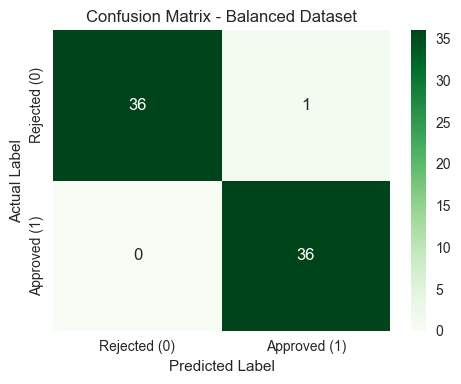


Classification Report - Balanced Dataset
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        37
           1       0.97      1.00      0.99        36

    accuracy                           0.99        73
   macro avg       0.99      0.99      0.99        73
weighted avg       0.99      0.99      0.99        73



In [14]:
# Predict holdout balanced
holdout_pred_bal = predict_model(tuned_model_bal)

y_true_bal = holdout_pred_bal["Status"]
y_pred_bal = holdout_pred_bal["prediction_label"]

cm_bal = confusion_matrix(y_true_bal, y_pred_bal)

plt.figure(figsize=(5,4))
sns.heatmap(cm_bal, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=["Rejected (0)", "Approved (1)"],
            yticklabels=["Rejected (0)", "Approved (1)"])

plt.title("Confusion Matrix - Balanced Dataset")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

print("\nClassification Report - Balanced Dataset")
print(classification_report(y_true_bal, y_pred_bal))

In [15]:
# Finalize model
final_model_bal = finalize_model(tuned_model_bal)

# Ambil estimator internal
model = final_model_bal.named_steps['actual_estimator']

# Ambil importance
importances = model.feature_importances_

# Ambil feature setelah preprocessing
X_processed = final_model_bal[:-1].transform(
    df_balanced.drop(columns=['Status'])
)

feature_names = X_processed.columns

# Samakan panjang (hindari mismatch)
feature_names = feature_names[:len(importances)]

# Bersihkan whitespace
clean_feature_names = (
    pd.Series(feature_names)
      .astype(str)
      .str.strip()
)

# Buat DataFrame
fi_df = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance': importances
})

# Hapus importance 0
fi_df = fi_df[fi_df['Importance'] > 0]

# Sort descending
fi_df = fi_df.sort_values(by='Importance', ascending=False)

fi_df

,Feature,Importance
47,Years_of_Working,8.306168e-01
48,Total_Bad_Debt,1.434912e-01
45,Total_Family_Members,2.420153e-02
6,Income_Type_Working,1.245845e-03
27,Owned_Phone,4.018637e-04
13,Education_Type_Lower secondary,1.445961e-05
32,Job_Title_Laborers,1.204286e-05
44,Job_Title_Secretaries,6.599479e-06
46,Applicant_Age,5.365368e-06
15,Family_Status_Single / not married,4.302543e-06


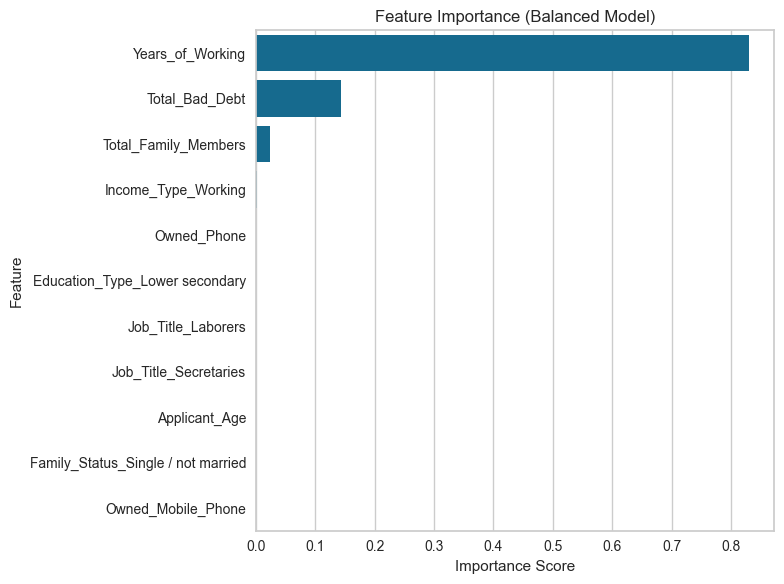

In [16]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=fi_df,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance (Balanced Model)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [17]:
# Save the final model
save_model(final_model_bal, "credit_card_approval_final_model")

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Owned_Car', 'Owned_Realty',
                                              'Total_Children', 'Total_Income',
                                              'Owned_Mobile_Phone',
                                              'Owned_Work_Phone', 'Owned_Phone',
                                              'Owned_Email',
                                              'Total_Family_Members',
                                              'Applicant_Age',
                                              'Years_of_Working',
                                              'Total_Bad_Debt',
                                              'Total_Good_Debt'],
                                     transformer=SimpleImpu...
                                             criterion='friedman_mse', init=None,
                               